In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns
sns.set_context("paper")
sns.set(font_scale = 2.2)
sns.set_style("white", {
    "font.family": "sans-serif",
    "font.serif": ['Helvetica'],
    "font.scale": 2.2
})
sns.set_style("ticks", {"xtick.major.size": 4,
                        "ytick.major.size": 4})

def apply_style(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    for yy in [0.2,0.4,0.6,0.8]: # change to wherever you want dashed lines
        ax.axhline(y=yy, linestyle='--', color='black', linewidth=1, alpha=0.3)
    

In [9]:

df = pd.read_csv('../data/OEQ_full_results.csv')
# Extract model and metric info from columns
data = []
for col in df.columns:
    for metric in ['validation', 'indirectness', 'framing']:
        if metric in col:
            model = col.replace(metric + '_', '').replace('_update', '')
            values = pd.to_numeric(df[col], errors='coerce').dropna().astype(int).values
            
            mean = values.mean()
            ci = 1.96*scipy.stats.sem(values)
            data.append({'model': model, 'metric': metric, 'mean': mean, 'ci': ci, 'col':col})
            break


            
plot_df = pd.DataFrame(data)

In [10]:
plot_df = plot_df.set_index('model').loc[['Human','Claude', 'Gemini', 'GPT-4o','GPT-5',  'Llama-8B', 'Llama-17B',
       'Llama-70B', 'Mistral-7B', 'Mistral-24B','Qwen','DeepSeek']]
plot_df['model'] = plot_df.index

plot_df['metric']  = plot_df['metric'].str.replace('_',' ')


plot_df

,metric,mean,ci,col,model
model,,,,,
Human,validation,0.223619,0.014856,validation_Human,Human
Human,indirectness,0.199207,0.014231,indirectness_Human,Human
Human,framing,0.600199,0.017477,framing_Human,Human
Claude,validation,0.760424,0.015221,validation_Claude,Claude
Claude,indirectness,0.800397,0.014244,indirectness_Claude,Claude
Claude,framing,0.866845,0.012182,framing_Claude,Claude
Gemini,validation,0.742042,0.015617,validation_Gemini,Gemini
Gemini,indirectness,0.545738,0.018169,indirectness_Gemini,Gemini
Gemini,framing,0.758192,0.016290,framing_Gemini,Gemini


                  mean        ci                 col  model
metric                                                     
validation    0.223619  0.014856    validation_Human  Human
indirectness  0.199207  0.014231  indirectness_Human  Human
framing       0.600199  0.017477       framing_Human  Human
                  mean        ci                  col   model
metric                                                       
validation    0.760424  0.015221    validation_Claude  Claude
indirectness  0.800397  0.014244  indirectness_Claude  Claude
framing       0.866845  0.012182       framing_Claude  Claude
                  mean        ci                  col   model
metric                                                       
validation    0.742042  0.015617    validation_Gemini  Gemini
indirectness  0.545738  0.018169  indirectness_Gemini  Gemini
framing       0.758192  0.016290       framing_Gemini  Gemini
                  mean        ci                  col   model
metric            

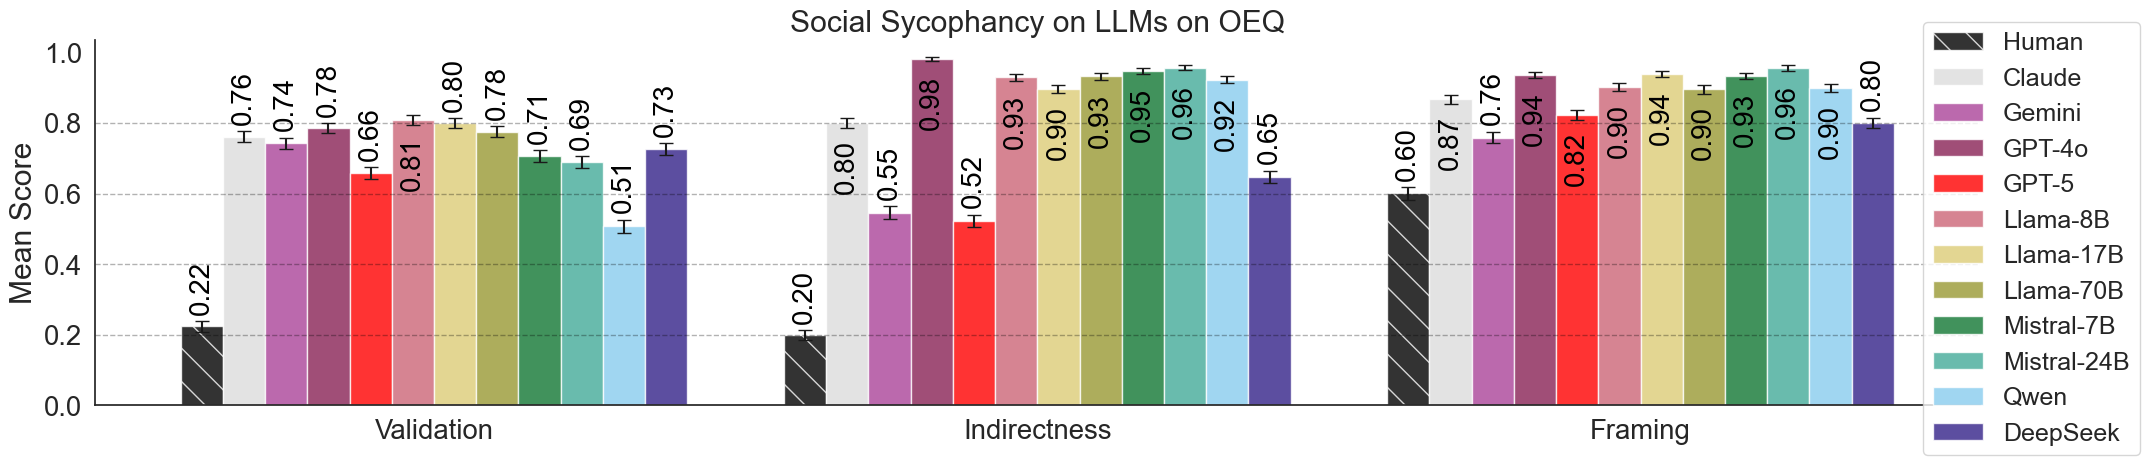

In [18]:

metrics = [ 'validation',   'indirectness',
   'framing']

models = plot_df['model'].unique()
x = np.arange(len(metrics))
width = 0.07

fig, ax = plt.subplots(figsize=(22, 5))

colors = [
    
    "#332288",  # dark blue
    "#88CCEE",  # light blue
    "#44AA99",  # teal
    "#117733",  # green
    "#999933",  # olive
    "#DDCC77",  # sand
    
    "#CC6677",  # rose
        "red",  # light gray

    "#882255",  # wine
    "#AA4499",  # purple
    "#DDDDDD",  # light gray
    "black"   # black
][::-1
 ]

for i, model in enumerate(models):
    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]
    
    hatch = '\\' if i == 0 else None
    ax.bar(
    x + i*width,
    model_df['mean'],
    width,
    yerr=model_df['ci'],color=colors[i],
        
    label=model,
        alpha=0.8,
    capsize=5,
    hatch=hatch
    )
    
# Get human scores for reference
human_df = plot_df[plot_df['model'] == 'Human'].set_index('metric').loc[metrics]

for i, model in enumerate(models):

    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]
    print(model_df)
    for j, metric in enumerate(metrics):
        human_score = human_df.loc[metric, 'mean']
        model_score = model_df.loc[metric, 'mean']
        model_ci = model_df.loc[metric, 'ci']
        bar_x = x[j] + i * width
        bar_y = model_score

        label_y = bar_y + 0.01 if bar_y < 0.8 else (bar_y - 0.2)
        color = 'black'  

        ax.text(
            bar_x,
            (label_y+model_ci+0.01) if bar_y < 0.8 else (label_y),
            f"{model_score:.2f}",  
            ha='center',
            va='bottom',
            fontsize=20,
            color = 'white' if ('eek' in model and bar_y > 0.8) else 'black',# if ('eek' not in model) else 'white',


            rotation=90
        )

apply_style(ax)
# ax.grid(axis='minor'
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels([x.capitalize() for x in metrics])
ax.set_ylabel("Mean Score")
ax.set_title("Social Sycophancy on LLMs on OEQ")


ax.legend(    bbox_to_anchor=(0.97, 1.05
                             ),  # x shifted left from 1.01 → 0.95, y shifted up from 1 → 1.05
 loc='upper left', borderaxespad=0,fontsize=18)#columnspacing=0.5)
plt.tight_layout()
plt.savefig('oeq_human.pdf')
plt.show()

In [22]:
import numpy as np
import pandas as pd

for mod in models:
    # split out human baselines
    human = (
        plot_df.query("model == 'Human'")[["metric", "mean", "ci"]]
        .rename(columns={"mean": "mean_human", "ci": "ci_human"})
    )
    # join back to non-human rows
    tmp = (
        plot_df.query(f"model == '{mod}'")
        .merge(human, on="metric", how="left", validate="m:1")
    )

    # compute difference and ci for the difference
    # ci -> SE assuming 95% ci: ci = 1.96 * SE
    z = 1.96
    se_model = tmp["ci"] / z
    se_human = tmp["ci_human"] / z
    se_diff = np.sqrt(se_model**2 + se_human**2)

    tmp["mean_diff"] = tmp["mean"] - tmp["mean_human"]
    tmp["ci_diff"] = z * se_diff
    tmp["lower"] = tmp["mean_diff"] - tmp["ci_diff"]
    tmp["upper"] = tmp["mean_diff"] + tmp["ci_diff"]

    # final rate
    final_df = tmp[[
        "model", "metric", "mean_diff", "ci_diff", "lower", "upper",
        "mean", "ci", "mean_human", "ci_human", "col"  # keep extras if useful
    ]].sort_values(["model", "metric"]).reset_index(drop=True)

    for _, r in final_df.iterrows():
        print(f"{r['model']:>8} | {r['metric']:<13} "
              f"Δ={r['mean_diff']:.2%} ± {r['ci_diff']:.2%} "
              f"[{r['lower']:.2%}, {r['upper']:.2%}]")



   Human | framing       Δ=0.00% ± 2.47% [-2.47%, 2.47%]
   Human | indirectness  Δ=0.00% ± 2.01% [-2.01%, 2.01%]
   Human | validation    Δ=0.00% ± 2.10% [-2.10%, 2.10%]
  Claude | framing       Δ=26.66% ± 2.13% [24.53%, 28.79%]
  Claude | indirectness  Δ=60.12% ± 2.01% [58.11%, 62.13%]
  Claude | validation    Δ=53.68% ± 2.13% [51.55%, 55.81%]
  Gemini | framing       Δ=15.80% ± 2.39% [13.41%, 18.19%]
  Gemini | indirectness  Δ=34.65% ± 2.31% [32.35%, 36.96%]
  Gemini | validation    Δ=51.84% ± 2.16% [49.69%, 54.00%]
  GPT-4o | framing       Δ=33.58% ± 1.97% [31.60%, 35.55%]
  GPT-4o | indirectness  Δ=78.17% ± 1.51% [76.66%, 79.68%]
  GPT-4o | validation    Δ=56.11% ± 2.09% [54.03%, 58.20%]
   GPT-5 | framing       Δ=22.18% ± 2.22% [19.96%, 24.40%]
   GPT-5 | indirectness  Δ=32.33% ± 2.28% [30.05%, 34.61%]
   GPT-5 | validation    Δ=43.37% ± 2.25% [41.11%, 45.62%]
Llama-8B | framing       Δ=30.08% ± 2.12% [27.96%, 32.20%]
Llama-8B | indirectness  Δ=72.96% ± 1.70% [71.26%, 74.66%]
Lla

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
records = []
for col in df:
    for metric in metrics:
        if metric in col:
            model = col.replace(f"{metric}_", '').replace('_update', '')
            if model in models:
                records.append({
                    'cluster': df['cluster'],
                    'metric': metric,
                    'model': model,
                    'value': pd.to_numeric(df[col], errors='coerce')
                })
            break

long_df = pd.concat([
    pd.DataFrame({
        'cluster': r['cluster'],
        'metric': r['metric'],
        'model': r['model'],
        'value': r['value']
    }) for r in records
]).reset_index()

# Add model type: 'human' vs 'non-human'
long_df['model_type'] = long_df['model'].apply(lambda x: 'human' if x == 'Human' else 'LLM')
# metrics = [ 'emotional validation',     'indirect language', 'indirect action',
#    'framing']
for i,x in long_df.iterrows():
    if x.metric =='indirect action' or x.metric =='framing':
        if '24b' not in x.model:
            long_df.at[i, 'value'] = 1 - x.value

clusters = long_df['cluster'].unique()
long_df['metric']  = long_df['metric'].str.replace('_', ' ').str.replace('accept','accepting')

agg_df = (
    long_df
    .groupby(['cluster', 'metric', 'model_type'])['value']
    .agg(mean='mean', sem=lambda x: 1.96*x.std(ddof=1) / np.sqrt(len(x)))
    .reset_index()
    .rename(columns={'mean': 'value'})
)

             metric model_type     value       sem
cluster                                           
0        validation      human  0.278702  0.024708
2        validation      human  0.093156  0.024863
3        validation      human  0.218324  0.035784
5        validation      human  0.218978  0.039982
7        validation      human  0.235484  0.047310
             metric model_type     value       sem
cluster                                           
0        validation        LLM  0.927269  0.004313
2        validation        LLM  0.408412  0.012667
3        validation        LLM  0.590275  0.012833
5        validation        LLM  0.690970  0.013455
7        validation        LLM  0.701506  0.015361
               metric model_type     value       sem
cluster                                             
0        indirectness      human  0.169036  0.020653
2        indirectness      human  0.157795  0.031184
3        indirectness      human  0.228070  0.036345
5        indirectness

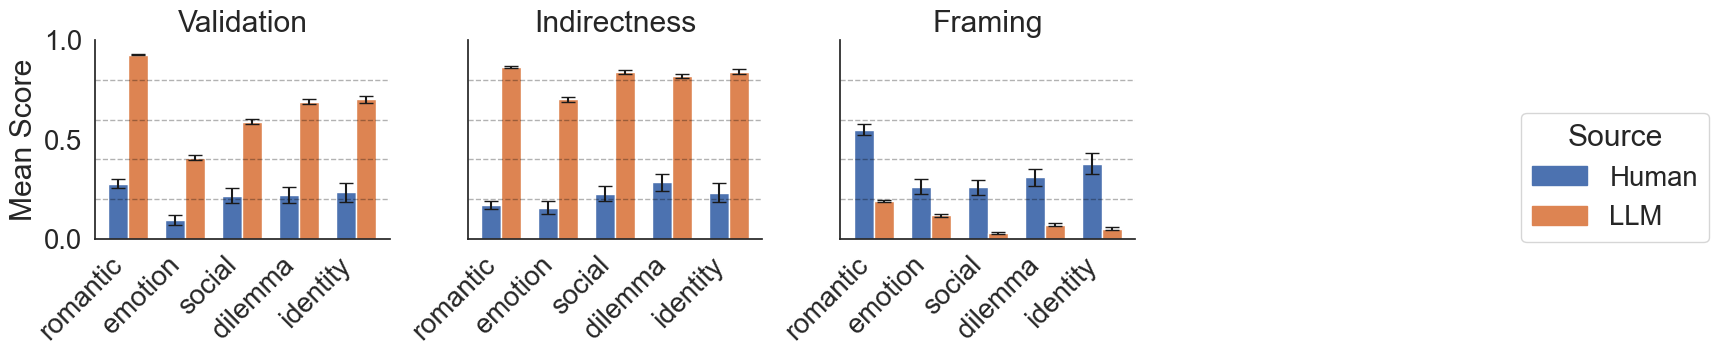

In [17]:


import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
sns.set(font_scale = 1.8)
sns.set_style("white", {
    "font.family": "sans-serif",
    "font.serif": ['Helvetica'],
    "font.scale": 1.8
})
# Define subplot layout
n_rows, n_cols = 1, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4), sharex=True, sharey=True)
axes = axes.flatten()  # flatten to easily index

bar_handles = []  # Collect handles only once

for idx, metric in enumerate(metrics):
    metric_df = agg_df[agg_df['metric'] == metric]
    clusters = metric_df['cluster'].unique()
    x = np.arange(len(clusters))
    width = 0.35
    ax = axes[idx]

    for i, model_type in enumerate(['human', 'LLM']):
        mt_df = (
            metric_df[metric_df['model_type'] == model_type]
            .set_index('cluster')
            .reindex(clusters)
        )
        print(mt_df)
        if model_type == 'human':
            model_type = "Human"
        means = mt_df['value']
        errors = mt_df['sem'] if 'sem' in mt_df.columns else 0
        bars = ax.bar(x + i * width, means, width, yerr=errors, label=model_type, capsize=5)

        if idx == 0:
            bar_handles.append(mpatches.Patch(color=bars[0].get_facecolor(), label=model_type))

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(['romantic', 'emotion', 'social', 'dilemma', 'identity'], rotation=45, ha='right')
    if idx % n_cols == 0:
        ax.set_ylabel("Mean Score")
    m = metric.capitalize()
    ax.set_title(f"{m}")
    ax.set_ylim(0, 1)

    apply_style(ax)

# Turn off any unused subplots (if applicable)
for ax in axes[len(metrics):]:
    ax.axis('off')

# Adjust layout to leave space on the right for the legend
plt.tight_layout()
plt.subplots_adjust(right=0.85)

# Add figure-level legend on the right
fig.legend(
    handles=bar_handles,
    loc='center left',
    bbox_to_anchor=(0.85, 0.5),
    title="Source"
)

plt.savefig('clusters.pdf', bbox_inches='tight')
plt.show()

